<center>
    <h1>Visualización de datos del COVID-19 en Colombia</h2>
</center>

<h2>
    Autor: Felipe Fernández Rodriguez
</h2>

In [149]:
# Librerías necesarias para el análisis de datos y visualización
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates # Librería extra para dar formato a las fechas en el eje X

In [150]:
# Librería para definir el path 
import os

# Nombre del archivo
filename = 'Casos_positivos_COVID-19_en_Colombia_limpios.csv'

# Se define el path
path = os.path.join(os.getcwd(), 'data', filename)

# Cargar el archivo CSV en un DataFrame de pandas
data_covid = pd.read_csv(path, index_col=0)

In [151]:
data_covid.info()

<class 'pandas.DataFrame'>
RangeIndex: 6390971 entries, 0 to 6390970
Data columns (total 31 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   fecha_reporte_web            str    
 1   id_de_caso                   str    
 2   fecha_de_notificacion        str    
 3   nombre_departamento          str    
 4   nombre_municipio             str    
 5   sexo                         str    
 6   tipo_de_contagio             str    
 7   ubicacion_del_caso           str    
 8   estado                       str    
 9   nombre_del_pais              str    
 10  recuperado                   str    
 11  fecha_de_inicio_de_sintomas  str    
 12  fecha_de_muerte              str    
 13  fecha_de_diagnostico         str    
 14  fecha_de_recuperacion        str    
 15  tipo_de_recuperacion         str    
 16  nombre_del_grupo_etnico      str    
 17  nombre_pertenencia_etnica    str    
 18  edad_años                    float64
 19  año_reporte

In [152]:
data_covid.columns

Index(['fecha_reporte_web', 'id_de_caso', 'fecha_de_notificacion',
       'nombre_departamento', 'nombre_municipio', 'sexo', 'tipo_de_contagio',
       'ubicacion_del_caso', 'estado', 'nombre_del_pais', 'recuperado',
       'fecha_de_inicio_de_sintomas', 'fecha_de_muerte',
       'fecha_de_diagnostico', 'fecha_de_recuperacion', 'tipo_de_recuperacion',
       'nombre_del_grupo_etnico', 'nombre_pertenencia_etnica', 'edad_años',
       'año_reporte_web', 'mes_reporte_web', 'año_notificaion',
       'mes_notificacion', 'año_inicio_sintomas', 'mes_inicio_sintomas',
       'año_muerte', 'mes_muerte', 'año_diagnostico', 'mes_diagnostico',
       'año_recuperacion', 'mes_recuperacion'],
      dtype='str')

In [153]:
data_covid.head()

,fecha_reporte_web,id_de_caso,fecha_de_notificacion,nombre_departamento,nombre_municipio,sexo,tipo_de_contagio,ubicacion_del_caso,estado,nombre_del_pais,...,año_notificaion,mes_notificacion,año_inicio_sintomas,mes_inicio_sintomas,año_muerte,mes_muerte,año_diagnostico,mes_diagnostico,año_recuperacion,mes_recuperacion
0,2020-12-24,"1,556,979",2020-12-22,VALLE,CALI,F,COMUNITARIA,CASA,LEVE,COLOMBIA,...,2020,12,2020.0,12.0,NaN,NaN,2020.0,12.0,2021.0,1.0
1,2020-12-24,"1,556,980",2020-12-19,VALLE,CALI,F,COMUNITARIA,CASA,LEVE,COLOMBIA,...,2020,12,2020.0,12.0,NaN,NaN,2020.0,12.0,2020.0,12.0
2,2020-12-24,"1,556,981",2020-12-19,VALLE,CALI,F,COMUNITARIA,CASA,LEVE,COLOMBIA,...,2020,12,2020.0,12.0,NaN,NaN,2020.0,12.0,2021.0,1.0
3,2020-12-24,"1,556,982",2020-12-22,VALLE,CALI,F,COMUNITARIA,FALLECIDO,FALLECIDO,COLOMBIA,...,2020,12,2020.0,12.0,2020.0,12.0,2020.0,12.0,NaN,NaN
4,2020-12-24,"1,556,983",2020-12-22,VALLE,CALI,F,COMUNITARIA,CASA,LEVE,COLOMBIA,...,2020,12,2020.0,12.0,NaN,NaN,2020.0,12.0,2021.0,1.0


<h3>
    Decodificación de las columnas fechas
</h3>

In [154]:
# Se define la lista con el nombre de las columnas que tienen información de fechas
columns_date = ['fecha_reporte_web', 'fecha_de_notificacion', 'fecha_de_inicio_de_sintomas', 'fecha_de_muerte', 'fecha_de_diagnostico', 'fecha_de_recuperacion']

# Transformación de las columnas a formato datetime
for column in columns_date:
    if column in data_covid.columns:
        data_covid[column] = pd.to_datetime(data_covid[column], errors='coerce')

data_covid.head()

,fecha_reporte_web,id_de_caso,fecha_de_notificacion,nombre_departamento,nombre_municipio,sexo,tipo_de_contagio,ubicacion_del_caso,estado,nombre_del_pais,...,año_notificaion,mes_notificacion,año_inicio_sintomas,mes_inicio_sintomas,año_muerte,mes_muerte,año_diagnostico,mes_diagnostico,año_recuperacion,mes_recuperacion
0,2020-12-24,"1,556,979",2020-12-22,VALLE,CALI,F,COMUNITARIA,CASA,LEVE,COLOMBIA,...,2020,12,2020.0,12.0,NaN,NaN,2020.0,12.0,2021.0,1.0
1,2020-12-24,"1,556,980",2020-12-19,VALLE,CALI,F,COMUNITARIA,CASA,LEVE,COLOMBIA,...,2020,12,2020.0,12.0,NaN,NaN,2020.0,12.0,2020.0,12.0
2,2020-12-24,"1,556,981",2020-12-19,VALLE,CALI,F,COMUNITARIA,CASA,LEVE,COLOMBIA,...,2020,12,2020.0,12.0,NaN,NaN,2020.0,12.0,2021.0,1.0
3,2020-12-24,"1,556,982",2020-12-22,VALLE,CALI,F,COMUNITARIA,FALLECIDO,FALLECIDO,COLOMBIA,...,2020,12,2020.0,12.0,2020.0,12.0,2020.0,12.0,NaN,NaN
4,2020-12-24,"1,556,983",2020-12-22,VALLE,CALI,F,COMUNITARIA,CASA,LEVE,COLOMBIA,...,2020,12,2020.0,12.0,NaN,NaN,2020.0,12.0,2021.0,1.0


<h3>
    Contagiados en Colombia, por fecha
</h3>

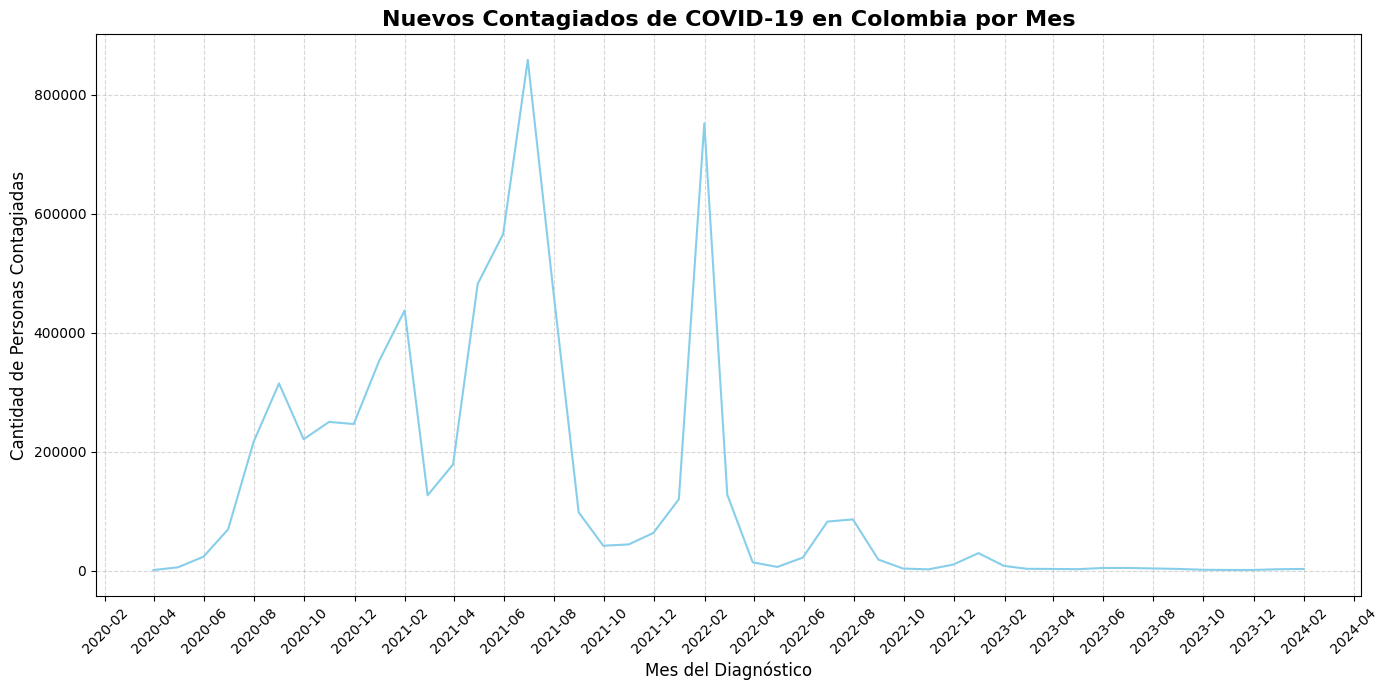

In [155]:
# Agrupamos por fecha de diagnostico
curve_colombia = data_covid.groupby('fecha_de_diagnostico').size()

# Agrupamos (resampleamos) los conteos por MES ('ME' = Month End) y sumamos
monthly_cases = curve_colombia.resample('ME').sum()

# Convertimos la Serie resultante de vuelta a un DataFrame para facilitar el graficado
df_graphic = monthly_cases.reset_index(name='cantidad_de_casos')

# Creamos la gráfica de línea
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_graphic, x='fecha_de_diagnostico', y='cantidad_de_casos', color='skyblue')

# Títulos y Etiquetas
plt.title('Nuevos Contagiados de COVID-19 en Colombia por Mes', fontsize=16, fontweight='bold')
plt.ylabel('Cantidad de Personas Contagiadas', fontsize=12)
plt.xlabel('Mes del Diagnóstico', fontsize=12)

# Configuramos para que muestre etiquetas cada 2 meses (para no amontonarlas)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
# Damos formato de Año-Mes (YYYY-MM) a las etiquetas
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
# Rotamos las etiquetas 45 grados para que se lean bien
plt.xticks(rotation=45)

# Cuadrícula
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout() # Ajusta automáticamente los márgenes

# Mostramos la gráfica
plt.show()

<h4>
    Conclusiones:
</h4>
<p>
    La curva de contagios en Colombia no fue lineal, sino que se caracterizó por múltiples olas, destacando dos picos críticos: a mediados de 2021 (tercer pico nacional) y a inicios de 2022 (ola de Ómicron).
</p>
<p>
    Los bajos volúmenes de casos reportados en el primer semestre de 2020 no reflejan la ausencia del virus, sino la limitada capacidad inicial de testeo y procesamiento de laboratorios en el país.
</p>
<p>
    A partir del segundo semestre de 2022, se observa un aplanamiento drástico y sostenido de la curva. Esto evidencia la transición de la pandemia a una fase endémica, impulsada fuertemente por la inmunización masiva y la protección natural adquirida por la población.
</p>

<h3>
    Contagiados en Antioquia, por fecha
</h3>

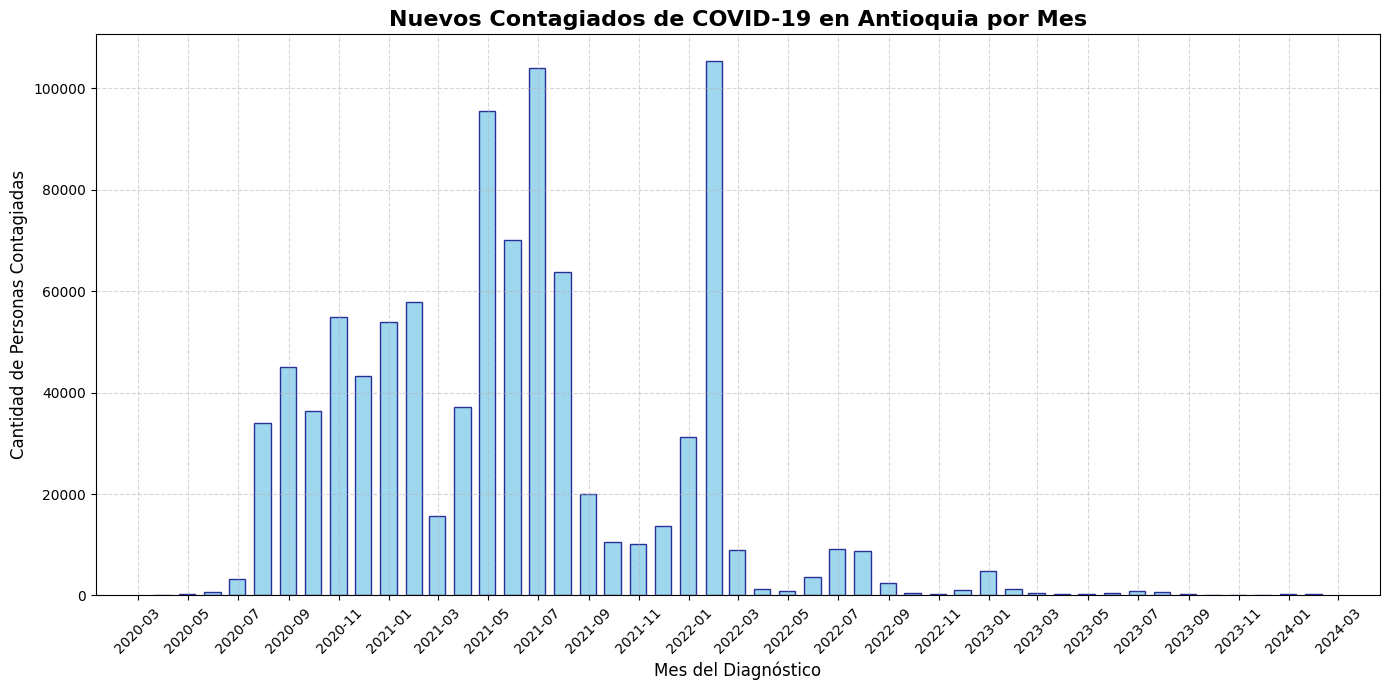

In [156]:
# Filtramos los datos para quedarnos solo con los casos de Antioquia
df_antioquia = data_covid[data_covid['nombre_departamento'] == 'ANTIOQUIA'].copy()

# Agrupamos por fecha de diagnostico
daily_cases_ant = df_antioquia.groupby('fecha_de_diagnostico').size()

# Agrupamos (resampleamos) los conteos por MES ('ME' = Month End) y sumamos
monthly_cases_ant = daily_cases_ant.resample('ME').sum()

# Convertimos la Serie resultante de vuelta a un DataFrame para facilitar el graficado
df_grafico = monthly_cases_ant.reset_index(name='cantidad_de_casos')

# Creamos la gráfica de barras
plt.figure(figsize=(14, 7))
plt.bar(df_grafico['fecha_de_diagnostico'], df_grafico['cantidad_de_casos'], color='skyblue', edgecolor='navy', width=20, alpha=0.8)

# Títulos y Etiquetas
plt.title('Nuevos Contagiados de COVID-19 en Antioquia por Mes', fontsize=16, fontweight='bold')
plt.ylabel('Cantidad de Personas Contagiadas', fontsize=12)
plt.xlabel('Mes del Diagnóstico', fontsize=12)

# Configuramos para que muestre etiquetas cada 2 meses (para no amontonarlas)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
# Damos formato de Año-Mes (YYYY-MM) a las etiquetas
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
# Rotamos las etiquetas 45 grados para que se lean bien
plt.xticks(rotation=45)

# Cuadrícula
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout() # Ajusta automáticamente los márgenes

# Mostramos la gráfica
plt.show()

<h4>
    Conclusiones:
</h4>
<p>
    La curva de infecciones en Antioquia refleja una altísima correlación con el comportamiento nacional. Debido a su densidad poblacional y alta movilidad económica, el departamento fue uno de los principales motores (y reflejos) de las dinámicas de contagio en Colombia.
</p>
<p>
    La barra individual más alta de toda la gráfica corresponde a enero de 2022. Esto evidencia visualmente la llegada de una nueva ola producida por alguna variante, demostrando una velocidad de transmisión sin precedentes en la región (un pico vertical), pero con una caída igualmente rápida en los meses posteriores.
</p>
<p>
    Al igual que en el panorama nacional, a partir del segundo semestre de 2022 los contagios caen drásticamente y se mantienen en una línea base muy baja. Esto refleja el éxito de las campañas de vacunación en los municipios antioqueños y la adaptación del sistema inmunológico de la población, pasando de una pandemia a una fase de control endémico.
</p>

<h3>
    Contagiados en Medellín, por fecha
</h3>

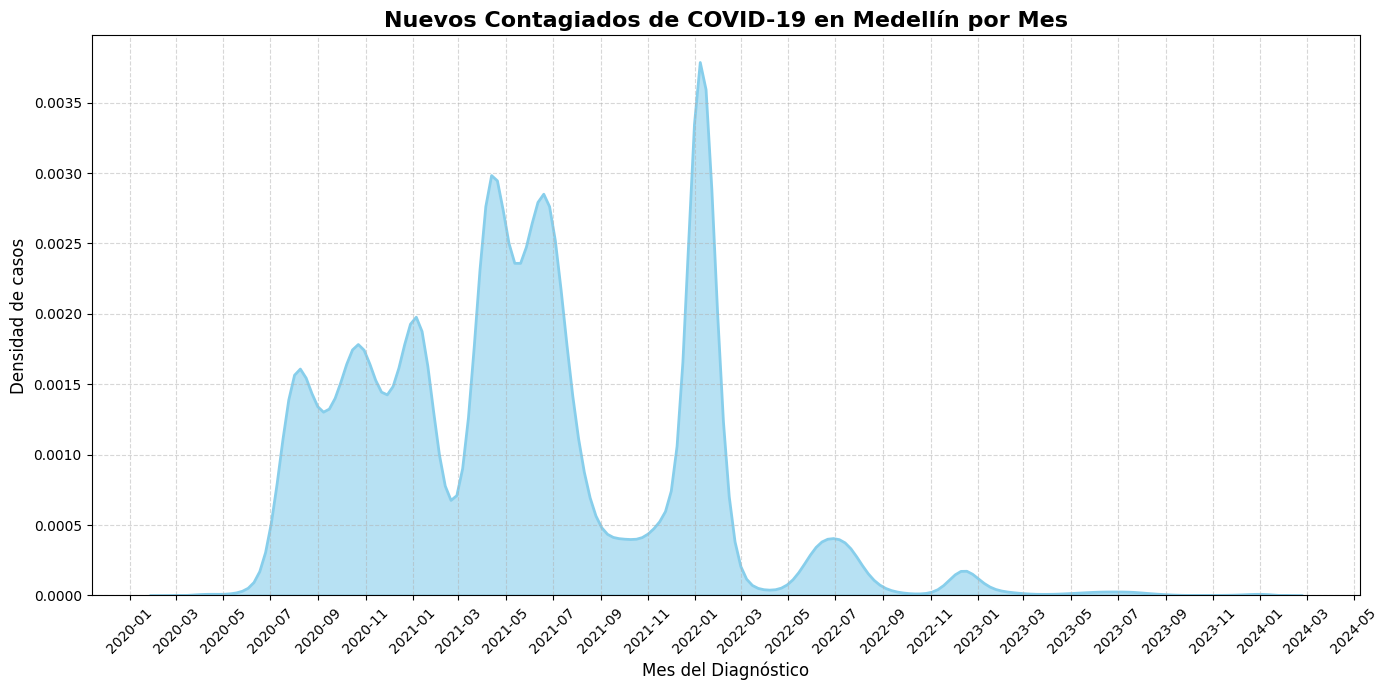

In [157]:
# Filtramos los datos para quedarnos solo con los casos de Antioquia
df_medellin = data_covid[data_covid['nombre_municipio'] == 'MEDELLIN'].copy()

# Creamos la gráfica de barras
plt.figure(figsize=(14, 7))
sns.kdeplot(df_medellin['fecha_de_diagnostico'], color='skyblue', fill=True, alpha=0.6, linewidth=2)

# Títulos y Etiquetas
plt.title('Nuevos Contagiados de COVID-19 en Medellín por Mes', fontsize=16, fontweight='bold')
plt.ylabel('Densidad de casos', fontsize=12)
plt.xlabel('Mes del Diagnóstico', fontsize=12)

# Configuramos para que muestre etiquetas cada 2 meses (para no amontonarlas)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
# Damos formato de Año-Mes (YYYY-MM) a las etiquetas
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
# Rotamos las etiquetas 45 grados para que se lean bien
plt.xticks(rotation=45)

# Cuadrícula
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout() # Ajusta automáticamente los márgenes

# Mostramos la gráfica
plt.show()

<h4>
    Conclusiones:
</h4>
<p>
    A diferencia de un solo brote aislado, la curva muestra que Medellín mantuvo una concentración alta y constante de casos durante el primer año. Se aprecian múltiples "olas" pequeñas y continuas (agosto 2020, octubre 2020, enero 2021), lo que refleja la dificultad inicial de contener el virus en una ciudad tan densamente poblada a pesar de las cuarentenas.
</p>
<p>
    Se observa una enorme montaña con dos puntas claras (bimodal) entre abril y julio de 2021. Este bloque masivo representa el momento de mayor crisis sanitaria en la ciudad (confinamientos escalonados y UCIs llenas), impulsado por la circulación de variantes agresivas y las dinámicas de reapertura.
</p>
<p>
    El punto más alto de toda la gráfica es inconfundible y ocurre a inicios de 2022. Su forma de "aguja" (muy alta y muy estrecha) nos dice dos cosas: la variante se propagó a una velocidad sin precedentes en la ciudad, pero así mismo, la ola pasó muy rápido en comparación con los meses de agonía del 2021.
</p>
<p>
    A partir de marzo de 2022, la densidad de diagnósticos cae drásticamente y se convierte en pequeñas "ondulaciones" cercanas a cero. Esto evidencia gráficamente que se ha logrado controlar la propagación del virus a niveles manejables.
</p>

<h3>
    Muertes en Colombia, por fecha
</h3>

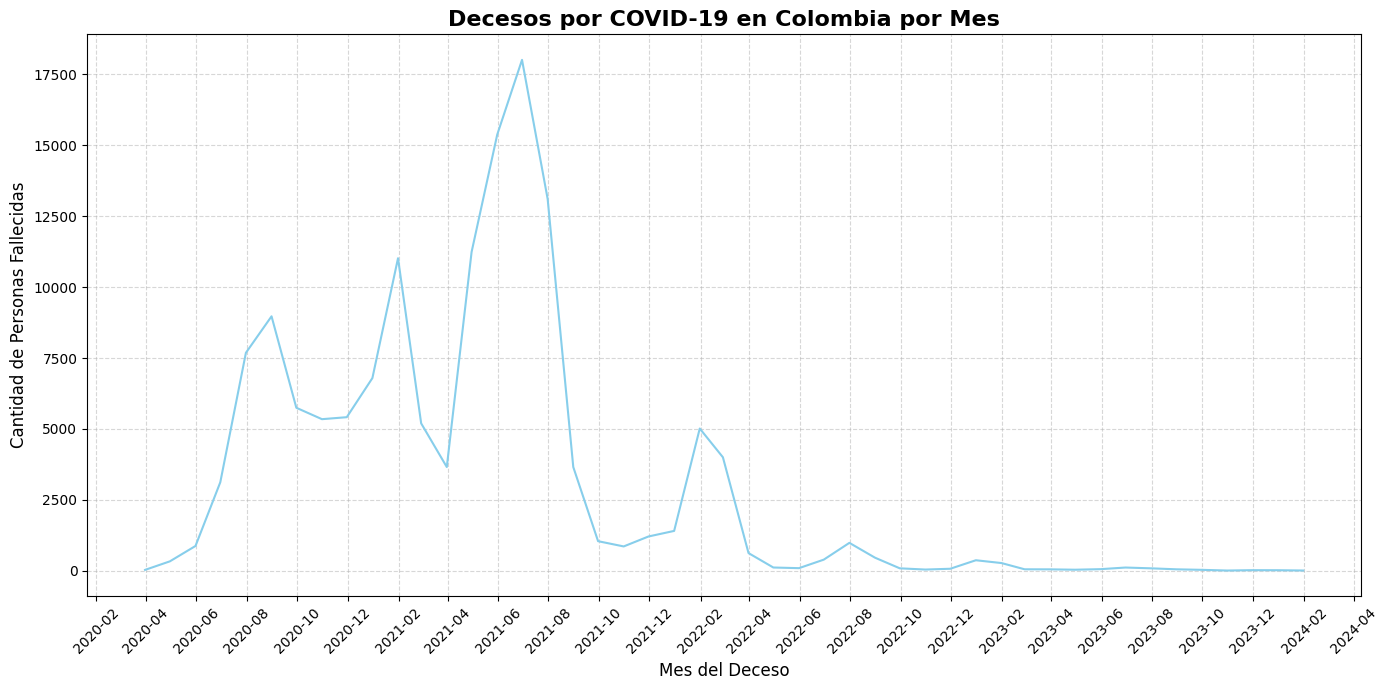

In [158]:
# Filtramos los datos para quedarnos solo con los casos donde la muerte fue por COVID-19
df_deaths = data_covid[data_covid['recuperado'] == 'FALLECIDO'].copy()

# Agrupamos por fecha de muerte
curve_colombia = df_deaths.groupby('fecha_de_muerte').size()

# Agrupamos (resampleamos) los conteos por MES ('ME' = Month End) y sumamos
monthly_cases = curve_colombia.resample('ME').sum()

# Convertimos la Serie resultante de vuelta a un DataFrame para facilitar el graficado
df_graphic = monthly_cases.reset_index(name='cantidad_de_decesos')

# Creamos la gráfica de línea
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_graphic, x='fecha_de_muerte', y='cantidad_de_decesos', color='skyblue')

# Títulos y Etiquetas
plt.title('Decesos por COVID-19 en Colombia por Mes', fontsize=16, fontweight='bold')
plt.ylabel('Cantidad de Personas Fallecidas', fontsize=12)
plt.xlabel('Mes del Deceso', fontsize=12)

# Configuramos para que muestre etiquetas cada 2 meses (para no amontonarlas)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
# Damos formato de Año-Mes (YYYY-MM) a las etiquetas
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
# Rotamos las etiquetas 45 grados para que se lean bien
plt.xticks(rotation=45)

# Cuadrícula
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout() # Ajusta automáticamente los márgenes

# Mostramos la gráfica
plt.show()

<h4>
    Conclusiones:
</h4>
<p>
    El momento más crítico de la pandemia en Colombia se ubica claramente entre junio y julio de 2021, donde se registró un pico histórico que rozó los 18,000 fallecimientos mensuales. Esto evidencia el impacto de la circulación de variantes altamente agresivas combinadas con un sistema de salud al límite, en una época donde la cobertura de vacunación aún no era masiva.
</p>
<p>
    Al comparar esta gráfica con la de contagios, se evidencia un fenómeno crucial en el cuarto pico (enero 2022). Mientras que los contagios se dispararon a niveles casi históricos (cerca de 750,000 casos), la curva de mortalidad de ese mismo mes se mantuvo drásticamente baja (alrededor de 5,000 decesos). Esta es la prueba estadística y visual de la baja letalidad, demostrando que aunque el virus seguía propagándose rápidamente, había perdido su capacidad de generar mortalidad masiva.
</p>
<p>
    Durante las primeras tres olas de la pandemia (2020 y 2021), la curva de decesos es un reflejo casi exacto de la curva de contagios, subiendo y bajando al mismo ritmo. Sin embargo, a partir de mediados de 2022, la curva de mortalidad se estabiliza cerca de la línea del cero de forma permanente, confirmando la transición definitiva hacia la fase endémica de la enfermedad en el país.
</p>

<h3>
    Muertes en Antioquia, por fecha
</h3>

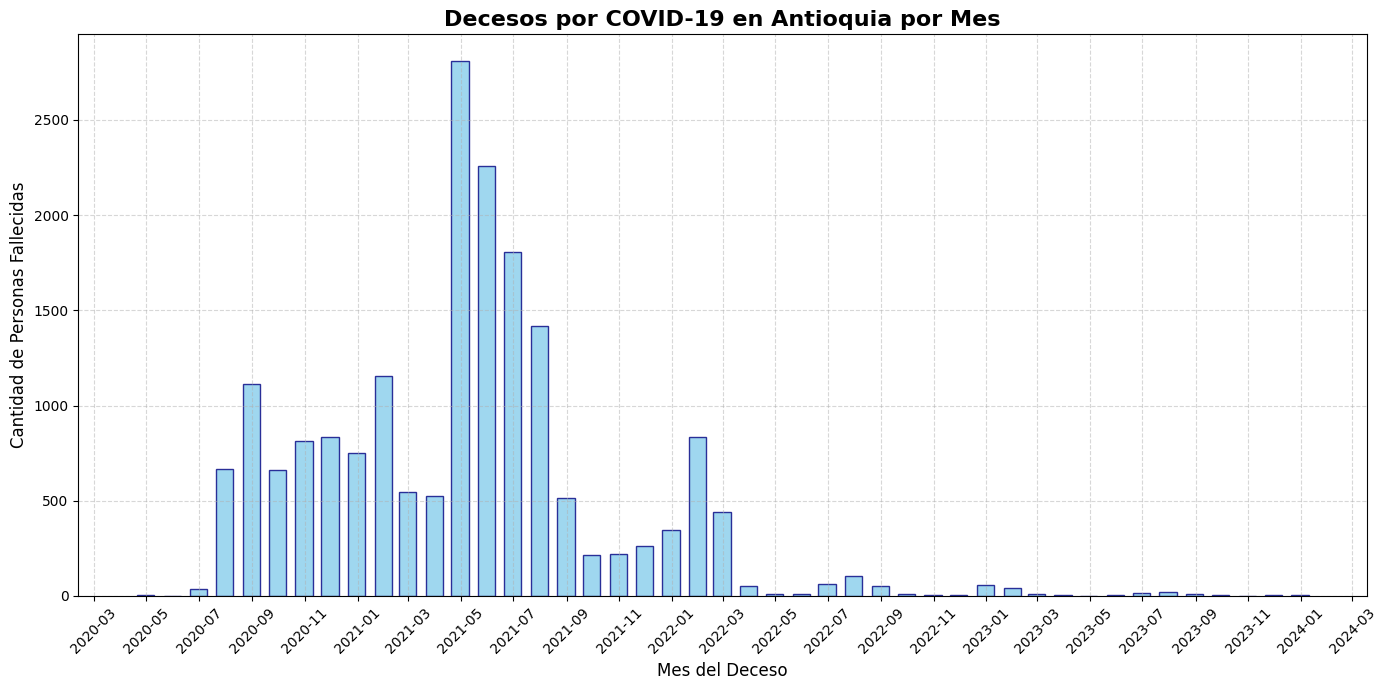

In [159]:

# Filtramos los datos para quedarnos solo con los casos donde la muerte fue por COVID-19 en Antioquia
df_antioquia = data_covid[(data_covid['recuperado'] == 'FALLECIDO') & (data_covid['nombre_departamento'] == 'ANTIOQUIA')].copy()

# Agrupamos por fecha de diagnostico
daily_cases_ant = df_antioquia.groupby('fecha_de_muerte').size()

# Agrupamos (resampleamos) los conteos por MES ('ME' = Month End) y sumamos
monthly_cases_ant = daily_cases_ant.resample('ME').sum()

# Convertimos la Serie resultante de vuelta a un DataFrame para facilitar el graficado
df_grafico = monthly_cases_ant.reset_index(name='cantidad_de_decesos')

# Creamos la gráfica de barras
plt.figure(figsize=(14, 7))
plt.bar(df_grafico['fecha_de_muerte'], df_grafico['cantidad_de_decesos'], color='skyblue', edgecolor='navy', width=20, alpha=0.8)

# Títulos y Etiquetas
plt.title('Decesos por COVID-19 en Antioquia por Mes', fontsize=16, fontweight='bold')
plt.ylabel('Cantidad de Personas Fallecidas', fontsize=12)
plt.xlabel('Mes del Deceso', fontsize=12)

# Configuramos para que muestre etiquetas cada 2 meses (para no amontonarlas)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
# Damos formato de Año-Mes (YYYY-MM) a las etiquetas
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
# Rotamos las etiquetas 45 grados para que se lean bien
plt.xticks(rotation=45)

# Cuadrícula
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout() # Ajusta automáticamente los márgenes

# Mostramos la gráfica
plt.show()

<h4>
    Conclusiones:
</h4>
<p>
    La gráfica muestra de forma contundente que el momento más oscuro para Antioquia ocurrió entre mayo y julio de 2021. La barra más alta roza los 3,000 fallecimientos en un solo mes. En el contexto local, esto coincide exactamente con las semanas de "Alerta Roja Hospitalaria" en el departamento.
</p>
<p>
    La barra de enero de 2022 apenas supera los 800 decesos. Comparando la gráfica de contagios de esta misma fecha demuestra que esta enorme diferencia visual es la prueba irrefutable de que, aunque el virus contagió a media región, se evitaron miles de fatalidades.
</p>
<p>
    A partir del segundo semestre de 2022, las barras caen dramáticamente y se vuelven casi imperceptibles. Esto confirma que Antioquia logró estabilizar la amenaza del virus, pasando de una emergencia de salud pública a una enfermedad endémica controlada.
</p>

<h3>
    Muertes en Medellín, por fecha
</h3>

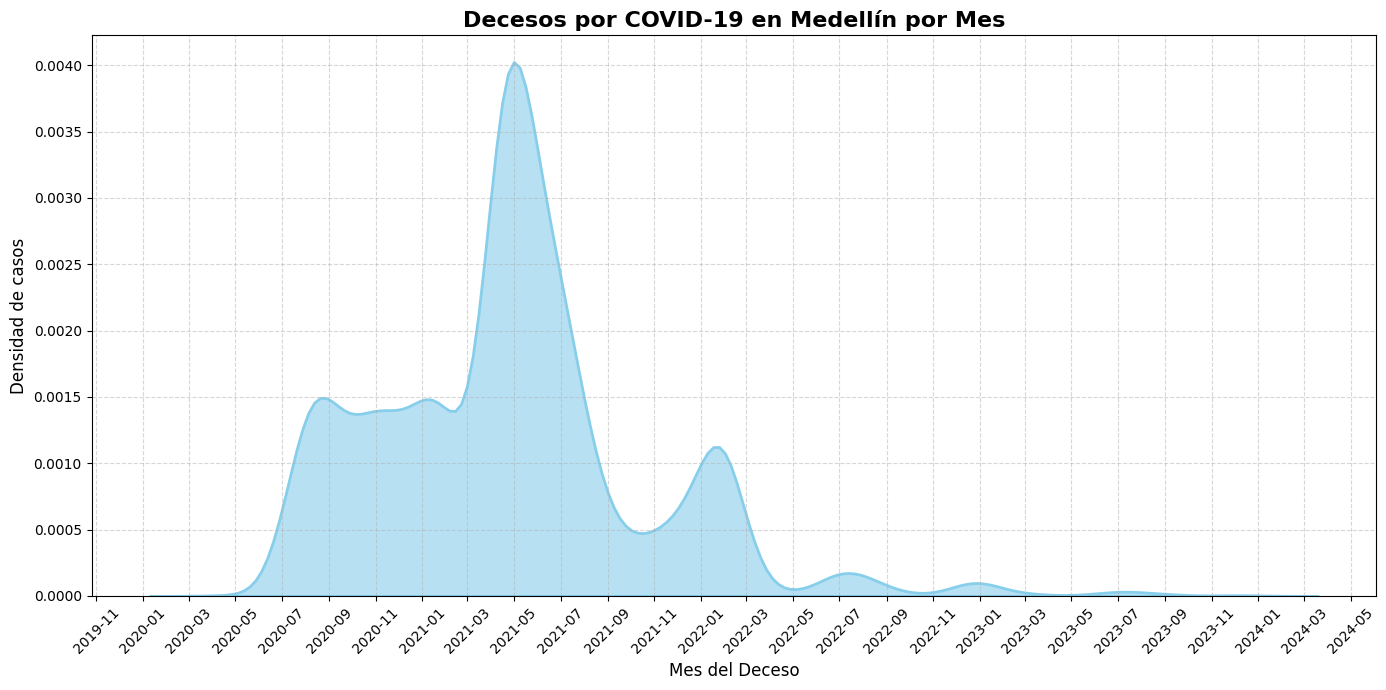

In [160]:
# Filtramos los datos para quedarnos solo con los casos donde la muerte fue por COVID-19 en Medellín
df_medellin = data_covid[(data_covid['recuperado'] == 'FALLECIDO') & (data_covid['nombre_municipio'] == 'MEDELLIN')].copy()

# Creamos la gráfica de barras
plt.figure(figsize=(14, 7))
sns.kdeplot(df_medellin['fecha_de_muerte'], color='skyblue', fill=True, alpha=0.6, linewidth=2)

# Títulos y Etiquetas
plt.title('Decesos por COVID-19 en Medellín por Mes', fontsize=16, fontweight='bold')
plt.ylabel('Densidad de casos', fontsize=12)
plt.xlabel('Mes del Deceso', fontsize=12)

# Configuramos para que muestre etiquetas cada 2 meses (para no amontonarlas)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
# Damos formato de Año-Mes (YYYY-MM) a las etiquetas
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
# Rotamos las etiquetas 45 grados para que se lean bien
plt.xticks(rotation=45)

# Cuadrícula
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout() # Ajusta automáticamente los márgenes

# Mostramos la gráfica
plt.show()

<h4>
    Conclusiones:
</h4>
<p>
    La curva de densidad alcanza su punto máximo absoluto (la gran "montaña" central) entre abril y julio de 2021. Al ser la gráfica de densidad de Medellín, esto refleja la época de mayor estrés para la red hospitalaria de la ciudad.
</p>
<p>
    Esta es la conclusión más importante. Si recordamos la gráfica de contagios de Medellín, la ola de inicios de 2022 fue una "aguja" gigante que rompió todos los récords de infección. Sin embargo, en esta gráfica de muertes, esa misma ola apenas representa un montículo pequeño (aproximadamente una cuarta parte de la densidad del pico de 2021).
</p>
<p>
    Entre el 2020 e inicios del 2021 a diferencia de un pico rápido, el primer año de la pandemia en Medellín muestra una meseta ondulada y prolongada. Esto nos indica que, a pesar de las cuarentenas y restricciones de movilidad, la ciudad mantuvo una tasa de mortalidad constante y dolorosa durante varios meses continuos.
</p>
<p>
    A partir del segundo trimestre de 2022, la curva de densidad de fallecimientos desciende dramáticamente y se "aplana" casi al nivel de cero. Esto confirma que Medellín logró superar la fase crítica de emergencia sanitaria, logrando convivir con el virus bajo un panorama de letalidad controlada.
</p>

<h3>
    Pairplot
</h3>

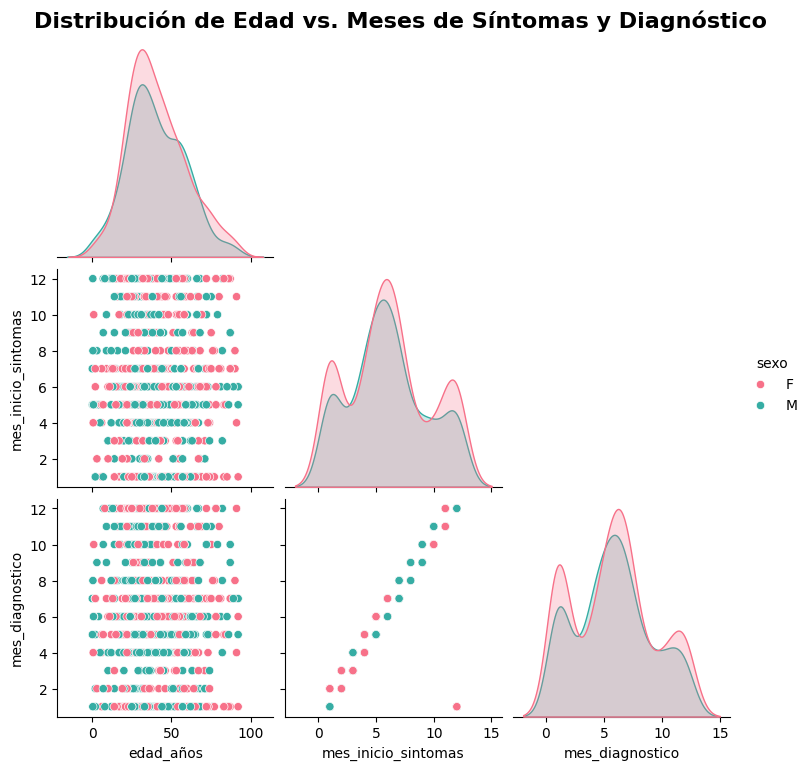

In [161]:
# Seleccionamos las columnas numéricas y una de texto para el color
columnas_pair = ['edad_años', 'mes_inicio_sintomas', 'mes_diagnostico', 'sexo']

# Filtramos nulos y sacamos una muestra de 1000
df_muestra = data_covid[columnas_pair].dropna().sample(n=1000, random_state=42)

# Creamos el pairplot coloreando por sexo
sns.pairplot(df_muestra, hue='sexo', palette='husl', corner=True)

# Ajustamos el título general
plt.suptitle('Distribución de Edad vs. Meses de Síntomas y Diagnóstico', y=1.02, fontsize=16, fontweight='bold')

# Mostramos el resultado
plt.show()

<h4>
    Conclusiones:
</h4>
<p>
    El virus no discriminó por sexo (igualdad de contagio), en todas las gráficas (tanto en las montañas como en los puntos), el color rojo (Femenino) y el color verde (Masculino) están casi perfectamente superpuestos. Esto significa que el comportamiento de la pandemia fue prácticamente idéntico para hombres y mujeres: se contagiaron a las mismas edades y en los mismos meses.
</p>
<p>
    La "montaña" de la esquina superior izquierda (Distribución de la edad). El pico más alto está entre los 20 y los 45 años. Esto tiene mucho sentido social: es la población económicamente activa, la que tenía que salir a trabajar, usar transporte público y exponerse más al virus, a diferencia de los niños o los ancianos que pudieron aislarse más fácil.
</p>
<p>
    La gráfica que cruza mes_inicio_sintomas con mes_diagnostico muestran los puntos forman una línea diagonal casi perfecta. Lo que significa que si una persona empezó con síntomas en el mes 5, fue diagnosticada en ese mismo mes 5. No hay puntos regados por todas partes, lo que demuestra que el sistema de salud (o la realización de pruebas) actuaba rápido y la gente no pasaba meses enferma antes de ser detectada.
</p>

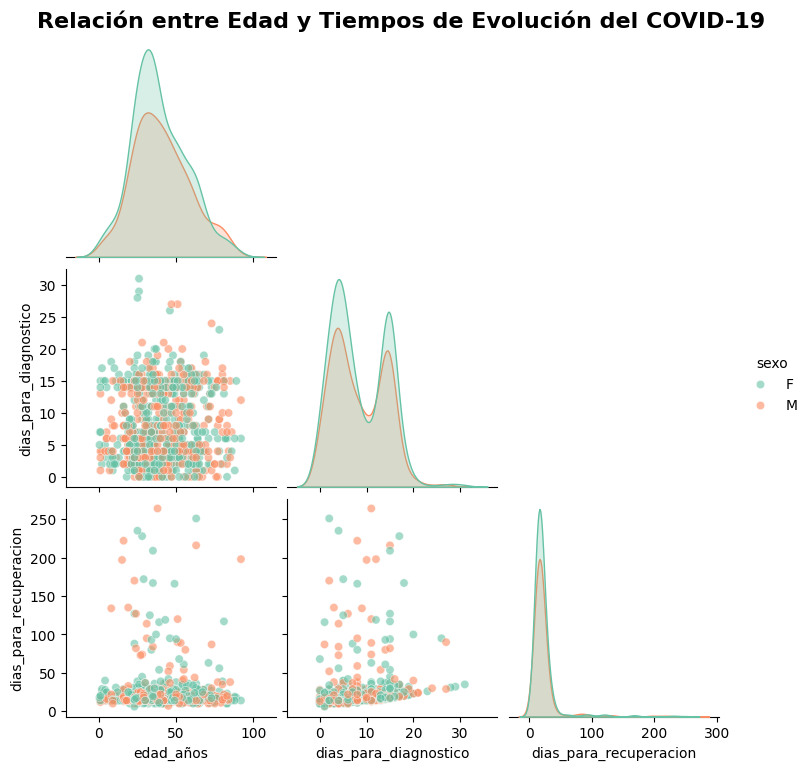

In [162]:
# Calculamos la diferencia en días usando .dt.days
data_covid['dias_para_diagnostico'] = (data_covid['fecha_de_diagnostico'] - data_covid['fecha_de_inicio_de_sintomas']).dt.days
data_covid['dias_para_recuperacion'] = (data_covid['fecha_de_recuperacion'] - data_covid['fecha_de_inicio_de_sintomas']).dt.days

# Filtro de limpieza: Convertimos a nulos los valores negativos (errores de digitación donde la fecha 2 es anterior a la fecha 1)
data_covid.loc[data_covid['dias_para_diagnostico'] < 0, 'dias_para_diagnostico'] = None
data_covid.loc[data_covid['dias_para_recuperacion'] < 0, 'dias_para_recuperacion'] = None

# Elegimos nuestras variables numéricas y agregamos 'sexo' para darle color a la gráfica
columns_pairplot = ['edad_años', 'dias_para_diagnostico', 'dias_para_recuperacion', 'sexo']

# Eliminamos nulos de este subconjunto y tomamos una muestra aleatoria de 1000 casos
df_pairplot = data_covid[columns_pairplot].dropna().sample(n=1000, random_state=42)

# Construir el Pairplot
# El parámetro 'hue' separará los datos por colores según la categoría (F o M)
# El parámetro 'corner=True' quita los gráficos repetidos de la parte superior derecha
grafica_matriz = sns.pairplot(df_pairplot, 
                              hue='sexo', 
                              palette='Set2', 
                              kind='scatter', 
                              diag_kind='kde', 
                              corner=True,
                              plot_kws={'alpha': 0.6})

# Ajustamos el título general
plt.suptitle('Relación entre Edad y Tiempos de Evolución del COVID-19', 
             y=1.02, fontsize=16, fontweight='bold')

# Mostramos el resultado
plt.show()

<h4>
    Conclusiones:
</h4>
<p>
    La gráfica de la esquina inferior izquierda (el cuadro de puntos que cruza dias_para_recuperacion con edad_años). La gran mayoría de los puntos están aplastados abajo (se recuperaron en menos de 30-40 días). Pero hay personas que tardaron 100, 150 y hasta más de 250 días en recuperarse. Esta es la evidencia estadística de los casos severos (largas estancias en UCI) y del fenómeno conocido como Long COVID (COVID prolongado).
</p>
<p>
    Las nubes de puntos, que están dispersas como cuadrados, no forman líneas diagonales claras. Lo que significa que variables como la edad no predecían exactamente los tiempos. Por ejemplo (cuadro inferior izquierdo), hubo jóvenes de 25 años que tardaron 200 días en recuperarse, y adultos mayores de 80 años que se recuperaron en 20 días. La gravedad y el tiempo de evolución dependían de otras variables clínicas (comorbilidades), no solo de la edad.
</p>
<p>
    Una vez más, las curvas y los puntos verdes (Femenino) y naranjas (Masculino) se superponen casi por completo en todas las gráficas. Esto confirma que el sexo biológico no fue un factor determinante ni en la velocidad con la que el sistema de salud entregaba los diagnósticos, ni en la cantidad de días promedio que tardaba el cuerpo en recuperarse.
</p>

<h3>
    Facegrid
</h3>

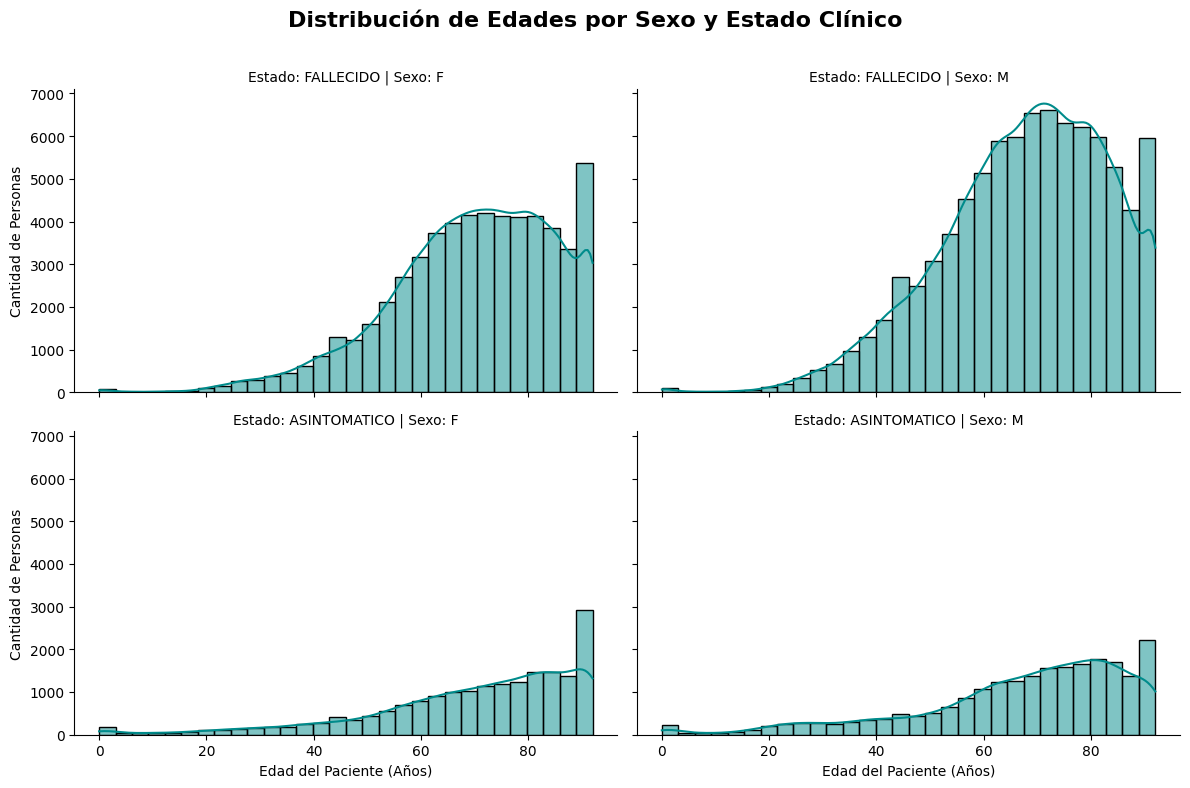

In [ ]:
# Filtramos solo los dos estados principales y los dos sexos (M y F)
df_facet = data_covid[
    (data_covid['estado'].isin(['FALLECIDO', 'ASINTOMATICO'])) & 
    (data_covid['sexo'].isin(['M', 'F']))
].copy()

# Crear la Cuadrícula (FacetGrid)
cuadricula = sns.FacetGrid(df_facet, col="sexo", row="estado", height=4, aspect=1.5)

# Adentro de cada cuadro dibuje un histograma (sns.histplot) de la columna 'edad_años'
cuadricula.map(sns.histplot, "edad_años", bins=30, kde=True, color="darkcyan")

# Ponemos nombres claros a los ejes de cada cuadro
cuadricula.set_axis_labels("Edad del Paciente (Años)", "Cantidad de Personas")

# Mejoramos los títulos individuales de cada cuadro
cuadricula.set_titles(col_template="Sexo: {col_name}", row_template="Estado: {row_name}")

# Título general (ajustamos el 'top' para que el título no se superponga con las gráficas)
cuadricula.figure.subplots_adjust(top=0.88)
cuadricula.figure.suptitle('Distribución de Edades por Sexo y Estado Clínico', fontsize=16, fontweight='bold')

# Mostramos  el resultado
plt.show()

<h4>
    Conclusiones:
</h4>
<p>
    La fila superior (Estado: FALLECIDO), muestra que ambas gráficas son como "montañas" que están totalmente recostadas hacia la derecha. La inmensa mayoría de los decesos empieza a escalar bruscamente a partir de los 50 años, concentrándose el pico máximo de muertes entre los 70 y 80 años. Esto confirma visualmente de forma irrefutable que la edad avanzada fue el principal factor de riesgo clínico frente al COVID-19.
</p>
<p>
    La comparación de las gráficas de la primera fila que compara los fallecimientos entre hombres y mujeres muestra una curva muy parecida, pero la de los hombres es mucho más alta (alcanzando cerca de 7,000 personas en su punto más alto, frente a las casi 4,500 de las mujeres). Esto demuestra estadísticamente que el virus tuvo una tasa de letalidad significativamente mayor en la población masculina.
</p>
<p>
    Al mirar la fila inferior (Estado: ASINTOMATICO), el comportamiento cambia drásticamente. Las curvas son muchísimo más planas, extendiéndose a lo largo de todo el eje horizontal. Lo que significa que la condición de ser "asintomático" se presentó de manera mucho más uniforme en todas las etapas de la vida. Jóvenes de 20, adultos de 40 y personas de 60 años tenían probabilidades similares de portar el virus sin desarrollar síntomas graves.
</p>